# Exploring CRE → CLS attention in VariantFormer

This notebook demonstrates how to use the `LogAttention` callback (added in the
`feature/attention-callback` branch) to extract per-layer, per-head attention
matrices during a forward pass of VariantFormer, and how to visualize the
attention from the **CLS / multi-registry token** (the tissue-specific
representation that the model pools to predict gene expression) over the
**cis-regulatory elements (CREs)** surrounding a gene.

This is the same kind of analysis the `gene_regulation/` pipeline performs in
the DNA2Cell repo: by reading the CLS row of the gene cross-attention matrix
(`gene_modulator_crossMHA_<layer>`), we can see which CREs the model 'looks
at' when summarizing the gene for a given tissue.

The notebook:

1. Loads a real `Seq2GenePredictorCombinedModulator` checkpoint (`v4_ag`,
   the all-genes model).
2. Builds a single-gene single-tissue batch from the example VCF
   (`HG00096.vcf.gz`) and the reference genome.
3. Runs one forward pass under `log_attn.record_attention(...)` to capture
   the attention matrices from a few layers of the gene modulator.
4. Plots the CLS row of the cross-attention as a function of CRE genomic
   position, plus per-head heatmaps and a layer comparison.

> **Requirements**: a CUDA GPU and the artifacts produced by
> `python download_artifacts.py` (model checkpoints, reference genome, VCF).

## 1. Setup

In [1]:
import os, sys, logging
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Walk up from cwd until we find the variantformer repo root (it contains
# the `processors/vcfprocessor.py` file). This works under Jupyter, VS Code,
# and `jupyter nbconvert --execute` without depending on ipynbname.
def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'processors' / 'vcfprocessor.py').exists():
            return p
    raise RuntimeError('Could not locate variantformer repo root')

REPO_PATH = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_PATH))

from processors.vcfprocessor import VCFProcessor
from seq2gene.attn_log_callback import LogAttention

logging.basicConfig(level=logging.WARNING, format='%(asctime)s %(levelname)s %(message)s')

assert torch.cuda.is_available(), 'This notebook requires a CUDA GPU.'
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Repo path: {REPO_PATH}')

GPU: NVIDIA H100 80GB HBM3
CUDA memory: 84.9 GB
Repo path: /work/variantformer


## 2. Pick a gene, a tissue, and a VCF

We use **APOE** (`ENSG00000130203.9`) on chromosome 19 with the example HG00096
VCF. APOE is a strongly tissue-regulated gene with well-characterized
regulatory elements, which makes it a good qualitative test case.

Feel free to change `gene_id`, `tissue`, and `vcf_path` to explore other
examples. The query format mirrors the one used in `notebooks/vcf2exp.ipynb`.

In [2]:
MODEL_CLASS = 'v4_ag'  # all-genes checkpoint (v4_pcg is protein-coding only)
GENE_ID = 'ENSG00000130203.9'  # APOE
TISSUE = 'whole blood'
VCF_PATH = str(REPO_PATH / '_artifacts' / 'HG00096.vcf.gz')

LAYERS_TO_LOG = [0, 6, 12, 18, 24]  # Sparse selection of the 25 layers

query_df = pd.DataFrame({'gene_id': [GENE_ID], 'tissues': [TISSUE]})
query_df

,gene_id,tissues
0,ENSG00000130203.9,whole blood


## 3. Build the dataset and load the model

`VCFProcessor` handles tokenization of the gene window and the surrounding
CREs, including any variants from the VCF. We load the checkpoint manually
instead of using `Trainer.predict` so we can wrap a single forward pass in
the `record_attention` context manager.

In [3]:
processor = VCFProcessor(model_class=MODEL_CLASS)
vcf_dataset, dataloader = processor.create_data(VCF_PATH, query_df)

model, ckpt_path, _trainer = processor.load_model()
state_dict = torch.load(ckpt_path, map_location='cpu', weights_only=False)
model.load_state_dict(state_dict.get('state_dict', state_dict), strict=False)
_ = model.cuda().eval()

# The model reads `self.trainer.precision` to know whether to autocast.
# We use bf16-mixed (matches the training setup) and let torch.amp do the cast.
model.trainer = type('T', (), {'precision': 'bf16-mixed'})()
print('Model loaded.')

2026-05-03 13:47:34 - processors.model_manager - INFO - Loading Seq2Reg model...


Loaded BPE vocabulary from /work/variantformer/vocabs/bpe_vocabulary_500.json
Filtered query df to 1 genes reducing from 1


2026-05-03 13:47:34 - processors.model_manager - INFO - Loading Seq2Reg gene model...


2026-05-03 13:47:34 - processors.model_manager - INFO - Creating Seq2Gene model...


2026-05-03 13:47:39 - processors.model_manager - INFO - Model class: <class 'seq2gene.model_combined_modulator.Seq2GenePredictorCombinedModulator'>


...

INFO: GPU available: True (cuda), used: True


2026-05-03 13:47:45 - lightning.pytorch.utilities.rank_zero - INFO - GPU available: True (cuda), used: True


INFO: TPU available: False, using: 0 TPU cores


2026-05-03 13:47:45 - lightning.pytorch.utilities.rank_zero - INFO - TPU available: False, using: 0 TPU cores


Model loaded.


## 4. Forward pass with attention logging

`LogAttention.record_attention(model)` flips the `log_attn_matrix` flag on
every selected encoder layer of the gene modulator (and optionally the
epigenetics modulator). During the forward pass the layer recomputes the
attention matrix in PyTorch (matching FlashAttention's output up to fp16
tolerance — see `tests/test_attn_log_callback.py`) and stores it in
`layer.attn_matrix`. On context exit the callback collects, processes, and
moves the matrices to CPU and resets the flags.

In [4]:
# keep_heads=True keeps the per-head dimension. Each per-batch entry is
# a (H, Q, K) tensor instead of being averaged to (Q, K).
log_attn = LogAttention(layer_ids=LAYERS_TO_LOG, log_heatmaps=False, keep_heads=True)

batch = next(iter(dataloader))
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        batch[k] = v.cuda()
    elif isinstance(v, list) and v and isinstance(v[0], torch.Tensor):
        batch[k] = [t.cuda() for t in v]

with torch.no_grad(), torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16):
    with log_attn.record_attention(model, log_epigenetics=False, log_gene=True):
        preds = model.predict_step(batch, 0)

print('Captured matrices:')
for name, mats in log_attn.attention_matrices.items():
    print(f'  {name}: list of {len(mats)} batches, first shape = {tuple(mats[0].shape)}')

pred_value = preds['pred_gene_exp'][0]
print(f'\nPredicted log-expression for {GENE_ID} in {TISSUE!r}: {float(pred_value.flatten()[0]):.3f}')

2026-05-03 13:47:52 - utils.assets - INFO - Loading parquet file: /work/variantformer/_artifacts/model/common/cres_all_genes_manifest.parquet


2026-05-03 13:47:52 - utils.assets - INFO - Validated schema - found columns: {'file_path', 'gene_id'}


Captured matrices:
  gene_modulator_crossMHA_0: list of 1 batches, first shape = (32, 7, 1367)
  gene_modulator_mixer_0: list of 1 batches, first shape = (32, 7, 7)
  gene_modulator_crossMHA_6: list of 1 batches, first shape = (32, 7, 1367)
  gene_modulator_mixer_6: list of 1 batches, first shape = (32, 7, 7)
  gene_modulator_crossMHA_12: list of 1 batches, first shape = (32, 7, 1367)
  gene_modulator_mixer_12: list of 1 batches, first shape = (32, 7, 7)
  gene_modulator_crossMHA_18: list of 1 batches, first shape = (32, 7, 1367)
  gene_modulator_mixer_18: list of 1 batches, first shape = (32, 7, 7)
  gene_modulator_crossMHA_24: list of 1 batches, first shape = (32, 7, 1367)
  gene_modulator_mixer_24: list of 1 batches, first shape = (32, 7, 7)

Predicted log-expression for ENSG00000130203.9 in 'whole blood': 1.520


## 5. Recover CRE genomic coordinates

The dataloader doesn't pass CRE coordinates through the batch — they are
consumed only as token IDs. We re-derive them from the same per-gene CRE
manifest the dataset uses (`gene_cre_manifest`) so we can plot attention
against genomic position.

Note: internally, the dataset extends each CRE by `cre_neighbour_hood`
(50 bp) on each side before tokenization (see
`ExtractSeqFromBed.apply_bcftools_consensus`), so each attention key
covers `[start_cre − 50, end_cre + 50]`. We don't materialize that padded
window in `cre_df` because adjacent CREs can be closer than 100 bp and
padded windows would visually overlap. Plots use the original cCRE
coordinates; the symmetric ±50 bp doesn't affect midpoints or distances
to the TSS.

In [5]:
from datasets.vcfdataset import multi_try_load_csv

gene_info = vcf_dataset._get_gene_info(GENE_ID)
gene_cre_path = vcf_dataset.gene_cre_manifest.get_file_path(GENE_ID)
cre_df = multi_try_load_csv(gene_cre_path)[
    ['chromosome', 'start_cre', 'end_cre', 'cre_name']
].copy()

# `ExtractSeqFromBed.process_subject` (the dataset's CRE extractor) sorts
# its output by ('chrom', 'start_cre') ascending. Mirror that here so the
# i-th row of `cre_df` aligns with the i-th CRE token the model saw. For
# minus-strand genes the dataset then reverses, which we replicate.
cre_df = cre_df.sort_values(['chromosome', 'start_cre']).reset_index(drop=True)
if gene_info['strand'] == '-':
    cre_df = cre_df.iloc[::-1].reset_index(drop=True)

cre_df['midpoint'] = (cre_df['start_cre'] + cre_df['end_cre']) // 2
tss = gene_info['start'] if gene_info['strand'] == '+' else gene_info['end']
cre_df['distance_to_tss'] = cre_df['midpoint'] - tss
if gene_info['strand'] == '-':
    cre_df['distance_to_tss'] = -cre_df['distance_to_tss']

print(f"Gene {GENE_ID} on {gene_info['chromosome']} strand={gene_info['strand']} TSS={tss}")
print(f'Number of CREs in manifest: {len(cre_df)}')
cre_df.head()

2026-05-03 13:48:11 - utils.assets - INFO - Loading parquet file: /work/variantformer/_artifacts/model/common/cres_all_genes_manifest.parquet


2026-05-03 13:48:11 - utils.assets - INFO - Validated schema - found columns: {'file_path', 'gene_id'}


Gene ENSG00000130203.9 on chr19 strand=+ TSS=44905754
Number of CREs in manifest: 1367


,chromosome,start_cre,end_cre,cre_name,midpoint,distance_to_tss
0,chr19,43914181,43914455,dELS,43914318,-991436
1,chr19,43926867,43927137,dELS,43927002,-978752
2,chr19,43928681,43928904,DNase-H3K4me3,43928792,-976962
3,chr19,43934062,43934410,"pELS,CTCF-bound",43934236,-971518
4,chr19,43934436,43934687,"pELS,CTCF-bound",43934561,-971193


## 6. Inspect the captured matrices

For `Seq2GenePredictorCombinedModulator` with `gene_pooling='multi_registry'`,
the gene cross-attention matrix has shape `(num_query_tokens, num_cre_tokens)`
where `num_query_tokens = 1 (CLS / registry) + num_gene_windows` and
`num_cre_tokens` equals the number of CREs surrounding the gene.

Because we passed `keep_heads=True` the callback retains the **head**
dimension, so each per-batch entry has shape
`(num_heads, num_query_tokens, num_cre_tokens)`. We average over heads here
to make the per-layer view; the per-head heatmap below uses the raw matrix
directly.

In [6]:
# Stack per-layer attention into a dict[layer_id] -> tensor[H, Q, K]
per_head_attention = {}      # raw, per-head
cls_attention = {}           # head-averaged CLS row, vs. CRE position
full_attention = {}          # head-averaged (Q, K), all gene tokens
K_attn = None                # number of CRE keys produced by the model
for name, mats in log_attn.attention_matrices.items():
    if not name.startswith('gene_modulator_crossMHA_'):
        continue
    layer_id = int(name.rsplit('_', 1)[-1])
    A_heads = mats[0].cpu().to(torch.float32).numpy()  # (H, Q, K)
    per_head_attention[layer_id] = A_heads
    A = A_heads.mean(axis=0)  # head-average: (Q, K)
    full_attention[layer_id] = A
    # The CLS / multi-registry token is the first query token.
    cls_attention[layer_id] = A[0]
    K_attn = A.shape[1]

# Reconcile manifest CRE count with attention key count.
#  * The attention K-dimension is the model's *padded* per-batch CRE token
#    length. Padded keys sit at the end of K and carry ~0 attention mass
#    (they're masked out before softmax).
#  * `ExtractSeqFromBed.process_subject` may also silently drop CREs whose
#    sequence extraction fails, so the model can see *fewer* CREs than the
#    manifest lists.
# Slice both sides to ``min(K_attn, len(cre_df))`` and warn if non-trivial.
n_aligned = min(K_attn, len(cre_df))
if n_aligned != len(cre_df) or n_aligned != K_attn:
    print(
        f'manifest CREs={len(cre_df)}, attention keys={K_attn}; '
        f'aligning to first {n_aligned} positions.'
    )
cre_df = cre_df.iloc[:n_aligned].reset_index(drop=True)
for layer_id in list(cls_attention):
    cls_attention[layer_id] = cls_attention[layer_id][:n_aligned]
x_kb = cre_df['distance_to_tss'].values / 1000.0  # used by the plots below

ordered_layers = sorted(cls_attention)
print('Cross-attention shapes:')
for layer_id in ordered_layers:
    print(
        f'  layer {layer_id:2d}: per_head={per_head_attention[layer_id].shape}  '
        f'full={full_attention[layer_id].shape}  cls_row={cls_attention[layer_id].shape}'
    )

Cross-attention shapes:
  layer  0: per_head=(32, 7, 1367)  full=(7, 1367)  cls_row=(1367,)
  layer  6: per_head=(32, 7, 1367)  full=(7, 1367)  cls_row=(1367,)
  layer 12: per_head=(32, 7, 1367)  full=(7, 1367)  cls_row=(1367,)
  layer 18: per_head=(32, 7, 1367)  full=(7, 1367)  cls_row=(1367,)
  layer 24: per_head=(32, 7, 1367)  full=(7, 1367)  cls_row=(1367,)


## 7. Plot CLS → CRE attention vs. distance to TSS

Each panel shows, for one layer, how strongly the CLS token attends to each
surrounding CRE as a function of (signed) distance from the TSS. Bars
increasing near 0 indicate the model relies more on promoter-proximal CREs;
bars at large distances indicate distal enhancer-like contributions.

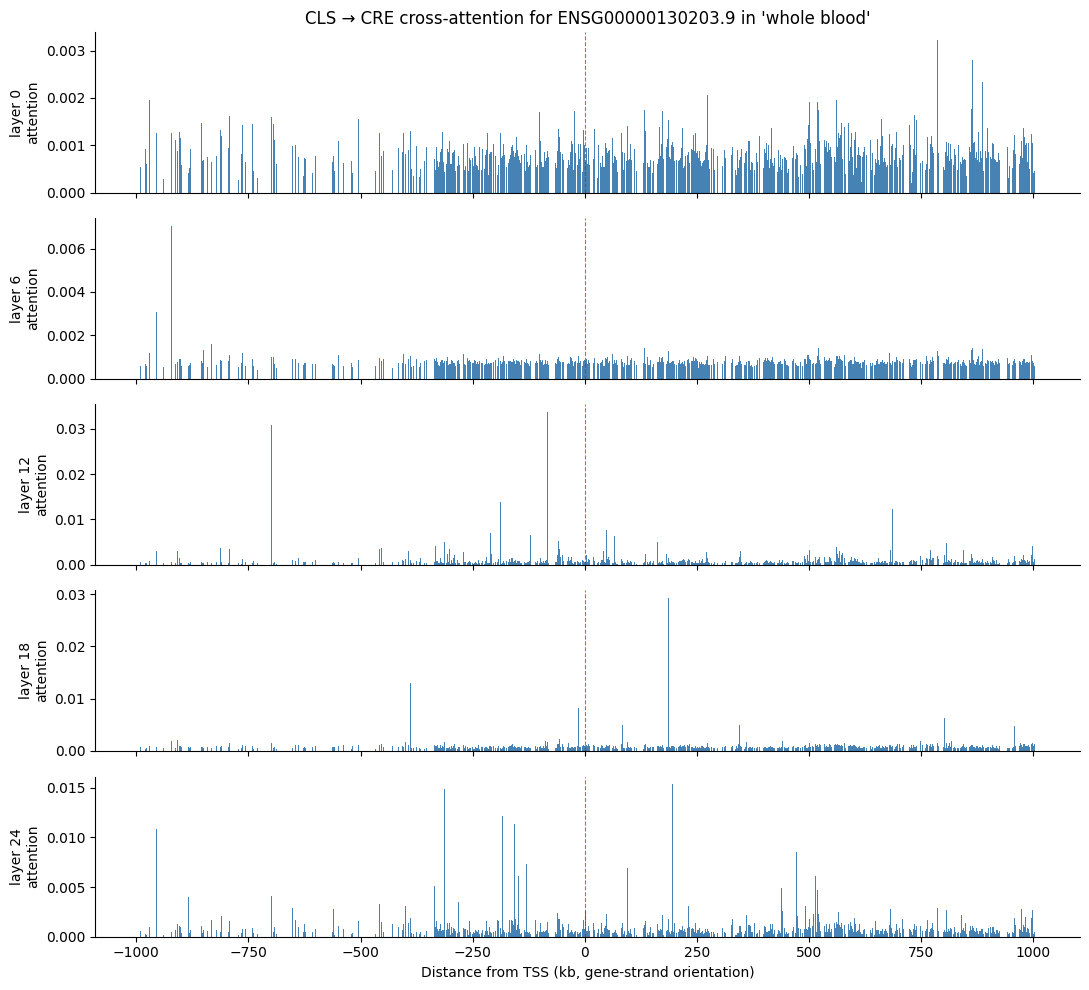

In [7]:
fig, axes = plt.subplots(
    len(ordered_layers), 1, figsize=(11, 2.0 * len(ordered_layers)), sharex=True
)
if len(ordered_layers) == 1:
    axes = [axes]

x_kb = cre_df['distance_to_tss'].values / 1000.0
for ax, layer_id in zip(axes, ordered_layers):
    weights = cls_attention[layer_id]
    ax.bar(x_kb, weights, width=2.0, color='steelblue', edgecolor='none')
    ax.axvline(0, color='red', lw=0.8, ls='--', alpha=0.7, label='TSS')
    ax.set_ylabel(f'layer {layer_id}\nattention')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axes[-1].set_xlabel('Distance from TSS (kb, gene-strand orientation)')
axes[0].set_title(f'CLS → CRE cross-attention for {GENE_ID} in {TISSUE!r}')
fig.tight_layout()
plt.show()

## 8. Top attended CREs (last layer)

Surfacing the actual cCRE names ranked by CLS attention weight is often the
most directly interpretable view: each row corresponds to one ENCODE candidate
regulatory element.

In [8]:
last_layer = ordered_layers[-1]
topk = 15
ranked = cre_df.copy()
ranked['attention'] = cls_attention[last_layer]
ranked = ranked.sort_values('attention', ascending=False).head(topk).reset_index(drop=True)
ranked[['cre_name', 'chromosome', 'start_cre', 'end_cre', 'distance_to_tss', 'attention']]

,cre_name,chromosome,start_cre,end_cre,distance_to_tss,attention
0,dELS,chr19,45100872,45101216,195290,0.015378
1,dELS,chr19,44592386,44592730,-313196,0.014920
2,"dELS,CTCF-bound",chr19,44722187,44722516,-183403,0.012141
3,"PLS,CTCF-bound",chr19,44748381,44748731,-157198,0.011394
4,"PLS,CTCF-bound",chr19,43951350,43951528,-954315,0.010851
5,"dELS,CTCF-bound",chr19,45443435,45443770,537848,0.008617
6,dELS,chr19,45376738,45376901,471065,0.008511
7,dELS,chr19,44774686,44774965,-130929,0.007328
8,pELS,chr19,45000297,45000474,94631,0.006891
9,pELS,chr19,44756812,44756968,-148864,0.006172


## 9. Full attention heatmap (gene tokens × CREs, last layer)

Beyond the CLS row, the cross-attention matrix has a row per gene window
token. Plotting the full matrix shows whether different gene windows pick
out different CREs or share roughly the same set.

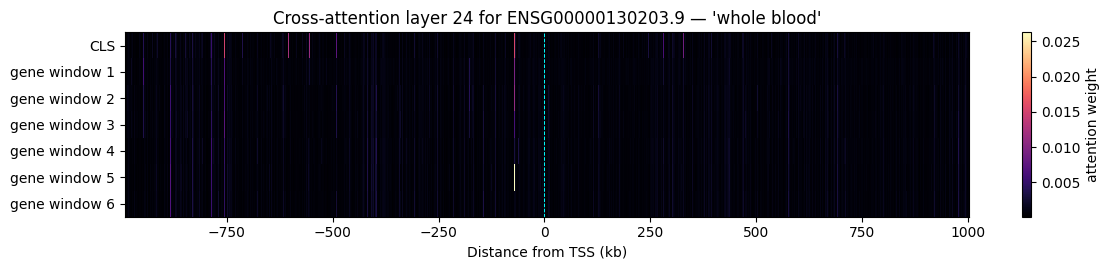

In [9]:
A = full_attention[last_layer][:, : len(cre_df)]
fig, ax = plt.subplots(figsize=(12, max(2.5, 0.4 * A.shape[0])))
im = ax.imshow(
    A,
    aspect='auto',
    cmap='magma',
    extent=[x_kb.min(), x_kb.max(), A.shape[0] - 0.5, -0.5],
    interpolation='nearest',
)
ax.axvline(0, color='cyan', lw=0.7, ls='--')
ax.set_yticks(np.arange(A.shape[0]))
y_labels = ['CLS'] + [f'gene window {i}' for i in range(1, A.shape[0])]
ax.set_yticklabels(y_labels)
ax.set_xlabel('Distance from TSS (kb)')
ax.set_title(f'Cross-attention layer {last_layer} for {GENE_ID} — {TISSUE!r}')
fig.colorbar(im, ax=ax, label='attention weight')
fig.tight_layout()
plt.show()

## 10. Per-head attention at the CLS row (last layer)

Because we recorded with `keep_heads=True`, the head-resolved matrices are
already in `per_head_attention`. No second forward pass is needed.

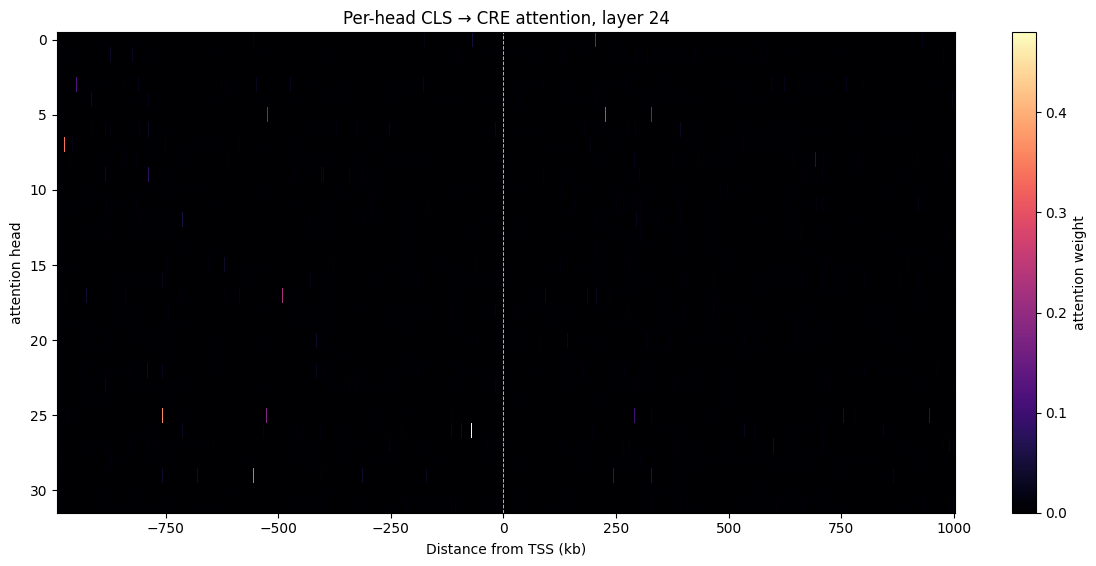

In [10]:
head_mats = per_head_attention[ordered_layers[-1]]  # (H, Q, K)
n_heads = head_mats.shape[0]
cls_per_head = head_mats[:, 0, : len(cre_df)]  # (H, K_real)

fig, ax = plt.subplots(figsize=(12, max(3, 0.18 * n_heads)))
im = ax.imshow(
    cls_per_head,
    aspect='auto',
    cmap='magma',
    extent=[x_kb.min(), x_kb.max(), n_heads - 0.5, -0.5],
    interpolation='nearest',
)
ax.axvline(0, color='cyan', lw=0.7, ls='--')
ax.set_xlabel('Distance from TSS (kb)')
ax.set_ylabel('attention head')
ax.set_title(f'Per-head CLS → CRE attention, layer {ordered_layers[-1]}')
fig.colorbar(im, ax=ax, label='attention weight')
fig.tight_layout()
plt.show()

## Recap

- `LogAttention(layer_ids=[...]).record_attention(model)` is the only thing
  needed to capture attention during a regular forward pass; it flips the
  layer-level `log_attn_matrix` flag on the way in and resets it on the way
  out.
- For `multi_registry` pooling, the **first row** of every
  `gene_modulator_crossMHA_<layer>` matrix is the CLS → CRE attention used
  for the gene-regulation analysis.
- The recompute is mathematically equivalent to FlashAttention's internal
  computation (verified in `tests/test_attn_log_callback.py::TestManualAttentionMatchesFlashAttention`).
- To go beyond a single gene, batch multiple `(gene_id, tissues)` rows in
  the query DataFrame and aggregate `log_attn.attention_matrices` across
  batches — each entry is a list of one tensor per batch.